In [1]:
!pip install numpy==1.26.4
!pip install scikit-learn==1.4.2
!pip install scikit-learn-extra==0.3.0

restart
  Using cached scikit_learn_extra-0.3.0-cp312-cp312-linux_x86_64.whl


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score

In [5]:
from google.colab import files
uploaded = files.upload()

Saving IRIS.csv to IRIS.csv


In [6]:
df = pd.read_csv('IRIS.csv')

In [7]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [9]:
df.isnull()

,sepal_length,sepal_width,petal_length,petal_width,species
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
145,False,False,False,False,False
146,False,False,False,False,False
147,False,False,False,False,False
148,False,False,False,False,False


In [10]:
df.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


In [11]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [12]:
df.shape

(150, 5)

In [13]:
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [15]:
kmedoids = KMedoids(
    n_clusters=3,
    random_state=42,
    metric='euclidean'
)

clusters = kmedoids.fit_predict(X_scaled)

In [16]:
df['Cluster'] = clusters

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,Cluster
0,5.1,3.5,1.4,0.2,Iris-setosa,0
1,4.9,3.0,1.4,0.2,Iris-setosa,0
2,4.7,3.2,1.3,0.2,Iris-setosa,0
3,4.6,3.1,1.5,0.2,Iris-setosa,0
4,5.0,3.6,1.4,0.2,Iris-setosa,0


In [17]:
score = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.4579479356469011


In [18]:
print(pd.crosstab(df['species'], df['Cluster']))

Cluster           0   1   2
species                    
Iris-setosa      50   0   0
Iris-versicolor   0  41   9
Iris-virginica    0  15  35


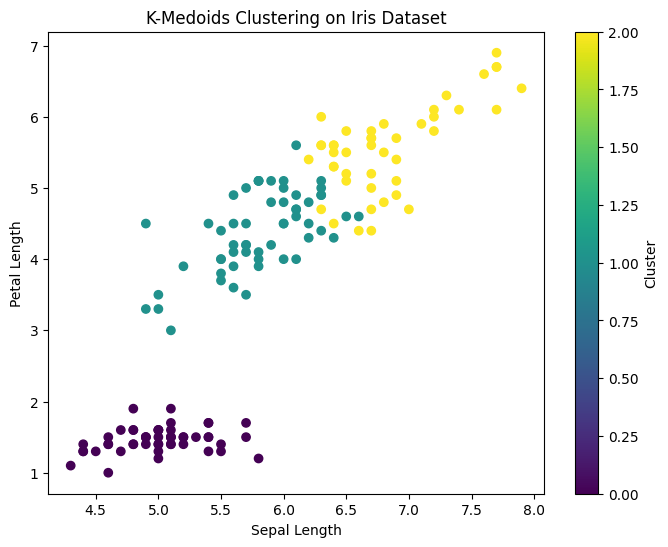

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['sepal_length'],
    df['petal_length'],
    c=df['Cluster'],
    cmap='viridis'
)

plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.title("K-Medoids Clustering on Iris Dataset")
plt.colorbar(label="Cluster")
plt.show()